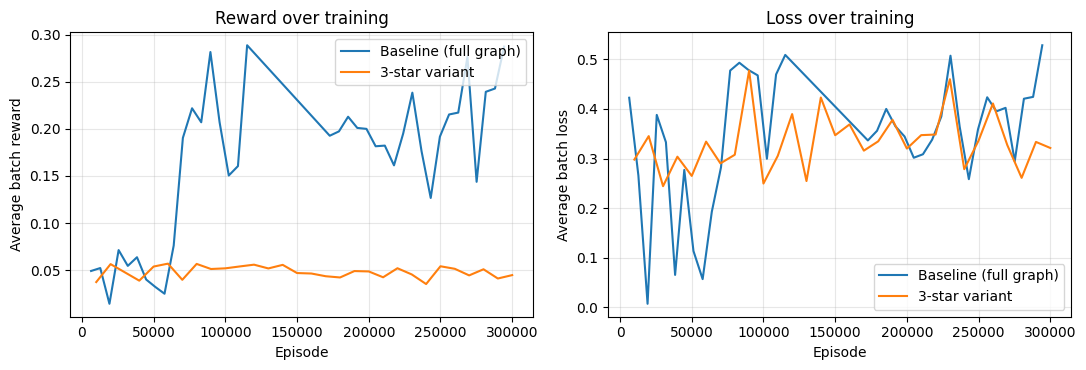

In [1]:
import re
import matplotlib.pyplot as plt

baseline_log = """
Episode 6400/300000 | Avg Batch Loss: 0.4227 | Avg Batch Reward: 0.0490
Episode 12800/300000 | Avg Batch Loss: 0.2657 | Avg Batch Reward: 0.0521
Episode 19200/300000 | Avg Batch Loss: 0.0068 | Avg Batch Reward: 0.0141
Episode 25600/300000 | Avg Batch Loss: 0.3881 | Avg Batch Reward: 0.0712
Episode 32000/300000 | Avg Batch Loss: 0.3329 | Avg Batch Reward: 0.0544
Episode 38400/300000 | Avg Batch Loss: 0.0651 | Avg Batch Reward: 0.0636
Episode 44800/300000 | Avg Batch Loss: 0.2770 | Avg Batch Reward: 0.0399
Episode 51200/300000 | Avg Batch Loss: 0.1133 | Avg Batch Reward: 0.0320
Episode 57600/300000 | Avg Batch Loss: 0.0566 | Avg Batch Reward: 0.0248
Episode 64000/300000 | Avg Batch Loss: 0.1927 | Avg Batch Reward: 0.0760
Episode 70400/300000 | Avg Batch Loss: 0.2823 | Avg Batch Reward: 0.1905
Episode 76800/300000 | Avg Batch Loss: 0.4776 | Avg Batch Reward: 0.2220
Episode 83200/300000 | Avg Batch Loss: 0.4933 | Avg Batch Reward: 0.2071
Episode 89600/300000 | Avg Batch Loss: 0.4786 | Avg Batch Reward: 0.2818
Episode 96000/300000 | Avg Batch Loss: 0.4678 | Avg Batch Reward: 0.2071
Episode 102400/300000 | Avg Batch Loss: 0.2995 | Avg Batch Reward: 0.1505
Episode 108800/300000 | Avg Batch Loss: 0.4697 | Avg Batch Reward: 0.1605
Episode 115200/300000 | Avg Batch Loss: 0.5091 | Avg Batch Reward: 0.2890
Episode 172800/300000 | Avg Batch Loss: 0.3365 | Avg Batch Reward: 0.1928
Episode 179200/300000 | Avg Batch Loss: 0.3560 | Avg Batch Reward: 0.1974
Episode 185600/300000 | Avg Batch Loss: 0.4001 | Avg Batch Reward: 0.2130
Episode 192000/300000 | Avg Batch Loss: 0.3650 | Avg Batch Reward: 0.2011
Episode 198400/300000 | Avg Batch Loss: 0.3444 | Avg Batch Reward: 0.2001
Episode 204800/300000 | Avg Batch Loss: 0.3016 | Avg Batch Reward: 0.1816
Episode 211200/300000 | Avg Batch Loss: 0.3086 | Avg Batch Reward: 0.1823
Episode 217600/300000 | Avg Batch Loss: 0.3380 | Avg Batch Reward: 0.1613
Episode 224000/300000 | Avg Batch Loss: 0.3847 | Avg Batch Reward: 0.1951
Episode 230400/300000 | Avg Batch Loss: 0.5075 | Avg Batch Reward: 0.2386
Episode 236800/300000 | Avg Batch Loss: 0.3645 | Avg Batch Reward: 0.1764
Episode 243200/300000 | Avg Batch Loss: 0.2583 | Avg Batch Reward: 0.1266
Episode 249600/300000 | Avg Batch Loss: 0.3589 | Avg Batch Reward: 0.1918
Episode 256000/300000 | Avg Batch Loss: 0.4236 | Avg Batch Reward: 0.2154
Episode 262400/300000 | Avg Batch Loss: 0.3952 | Avg Batch Reward: 0.2174
Episode 268800/300000 | Avg Batch Loss: 0.4023 | Avg Batch Reward: 0.2766
Episode 275200/300000 | Avg Batch Loss: 0.2945 | Avg Batch Reward: 0.1438
Episode 281600/300000 | Avg Batch Loss: 0.4207 | Avg Batch Reward: 0.2395
Episode 288000/300000 | Avg Batch Loss: 0.4244 | Avg Batch Reward: 0.2430
Episode 294400/300000 | Avg Batch Loss: 0.5286 | Avg Batch Reward: 0.2876
"""

threestar_log = """
Episode 10000/300000 | Avg Batch Loss: 0.2979 | Avg Batch Reward: 0.0372
Episode 20000/300000 | Avg Batch Loss: 0.3452 | Avg Batch Reward: 0.0563
Episode 30000/300000 | Avg Batch Loss: 0.2442 | Avg Batch Reward: 0.0475
Episode 40000/300000 | Avg Batch Loss: 0.3037 | Avg Batch Reward: 0.0387
Episode 50000/300000 | Avg Batch Loss: 0.2649 | Avg Batch Reward: 0.0537
Episode 60000/300000 | Avg Batch Loss: 0.3341 | Avg Batch Reward: 0.0568
Episode 70000/300000 | Avg Batch Loss: 0.2902 | Avg Batch Reward: 0.0396
Episode 80000/300000 | Avg Batch Loss: 0.3076 | Avg Batch Reward: 0.0565
Episode 90000/300000 | Avg Batch Loss: 0.4774 | Avg Batch Reward: 0.0511
Episode 100000/300000 | Avg Batch Loss: 0.2495 | Avg Batch Reward: 0.0518
Episode 110000/300000 | Avg Batch Loss: 0.3055 | Avg Batch Reward: 0.0538
Episode 120000/300000 | Avg Batch Loss: 0.3897 | Avg Batch Reward: 0.0557
Episode 130000/300000 | Avg Batch Loss: 0.2545 | Avg Batch Reward: 0.0517
Episode 140000/300000 | Avg Batch Loss: 0.4231 | Avg Batch Reward: 0.0555
Episode 150000/300000 | Avg Batch Loss: 0.3470 | Avg Batch Reward: 0.0468
Episode 160000/300000 | Avg Batch Loss: 0.3688 | Avg Batch Reward: 0.0463
Episode 170000/300000 | Avg Batch Loss: 0.3159 | Avg Batch Reward: 0.0434
Episode 180000/300000 | Avg Batch Loss: 0.3347 | Avg Batch Reward: 0.0421
Episode 190000/300000 | Avg Batch Loss: 0.3780 | Avg Batch Reward: 0.0489
Episode 200000/300000 | Avg Batch Loss: 0.3201 | Avg Batch Reward: 0.0485
Episode 210000/300000 | Avg Batch Loss: 0.3472 | Avg Batch Reward: 0.0423
Episode 220000/300000 | Avg Batch Loss: 0.3484 | Avg Batch Reward: 0.0519
Episode 230000/300000 | Avg Batch Loss: 0.4601 | Avg Batch Reward: 0.0453
Episode 240000/300000 | Avg Batch Loss: 0.2785 | Avg Batch Reward: 0.0351
Episode 250000/300000 | Avg Batch Loss: 0.3363 | Avg Batch Reward: 0.0540
Episode 260000/300000 | Avg Batch Loss: 0.4111 | Avg Batch Reward: 0.0513
Episode 270000/300000 | Avg Batch Loss: 0.3272 | Avg Batch Reward: 0.0443
Episode 280000/300000 | Avg Batch Loss: 0.2610 | Avg Batch Reward: 0.0508
Episode 290000/300000 | Avg Batch Loss: 0.3335 | Avg Batch Reward: 0.0410
Episode 300000/300000 | Avg Batch Loss: 0.3213 | Avg Batch Reward: 0.0446
"""

def parse_log(log_text):
    pattern = r"Episode (\d+)/\d+ \| Avg Batch Loss: ([-\d\.]+) \| Avg Batch Reward: ([-\d\.]+)"
    matches = re.findall(pattern, log_text)
    return [int(m[0]) for m in matches], [float(m[1]) for m in matches], [float(m[2]) for m in matches]

base_eps, base_losses, base_rewards = parse_log(baseline_log)
ts_eps, ts_losses, ts_rewards = parse_log(threestar_log)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].plot(base_eps, base_rewards, label="Baseline (full graph)", color='tab:blue')
axes[0].plot(ts_eps, ts_rewards, label="3-star variant", color='tab:orange')
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Average batch reward")
axes[0].set_title("Reward over training")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(base_eps, base_losses, label="Baseline (full graph)", color='tab:blue')
axes[1].plot(ts_eps, ts_losses, label="3-star variant", color='tab:orange')
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Average batch loss")
axes[1].set_title("Loss over training")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
plt.show()